# Project: Adaptive Spectral Forecasting (ASF)
## Research Notebook 01: Rethinking the Distributional Footprint 

## 1. Executive Summary & Project Lineage
### 1.1 From Tail-Risk (VaR) to Full-Density Forecasting
This project is a direct evolution of our previous research into Value at Risk (VaR) failures.The Past: Our [GitLab Repository Name] analyzed how standard VaR models fail by underestimating tail risk and assuming static distributions.The Present: We move beyond just the "left tail" to model the Full Probability Density Function (PDF). We aim to forecast how the entire distribution of an asset evolves by combining historical memory with external catalysts.


## 2. Motivation: The Strategic "Why"

### 2.1 For the Risk Manager (Stability & Capital Efficiency)

Regime Awareness: Detecting shifts from "Low-Volatility" to "High-Volatility" regimes before they trigger catastrophic VaR breaches.Capital Optimization: A better understanding of the distribution allows for more efficient margin usage and proactive deleveraging.

### 2.2 For the Trader (Alpha & Execution)Convexity & Skew: 

Identifying mispriced options by forecasting shifts in the distribution's skewness (the "bias" toward a rally or crash).Position Sizing: Using the full distribution to calculate the Kelly Criterion, optimizing trade size based on the expected utility rather than a simple point-target.

## 4. Methodology: 

The Augmented State SpaceWe reject the idea that price exists in a vacuum. Our model integrates two distinct streams:
Signal TypeCategoryExamplesPurposeEndogenousHistorical FootprintLog-Returns, Realized Vol, OHLCVCaptures market "inertia" and memory.ExogenousExternal CatalystsVIX, 10Y Yields, DXY, SentimentCaptures the "energy" driving the next move.


## 3. Problem Definition: 
The "Non-Stationarity" TrapStandard forecasting treats the market as if "gravity" stays the same. In reality, market distributions are Adversarial and Non-Stationary.

### 3.1 The "One Observation" Dilemma
For every predicted distribution, we only observe one realized price point per day. This makes traditional metrics like MSE (Mean Squared Error) insufficient. We must focus on:
- Calibration: Is our model "honest" about its uncertainty?
- Sharpness: Is our prediction narrow enough to be useful?

## 5. The Benchmark: 
GARCH(1,1) with Student-tBefore introducing advanced models (Neural SDEs/Signatures), we establish a Historical Floor.
- Model: A classical GARCH(1,1) model.
- Assumption: The future is a weighted average of recent volatility, following a fat-tailed Student-t distribution.
- The Goal: If our "High-Impact" model cannot beat this simple benchmark in CRPS (Continuous Ranked Probability Score), the added complexity is not justified.

## 6. Success Metrics & Evaluation Framework
We define success through three lenses:
- Statistical (PIT Test): We use the Probability Integral Transform. If our distributions are correct, the CDF values of actual returns should be uniformly distributed $U(0,1)$.
- Information Gain (Log-Likelihood): Maximizing the probability that the realized data belonged to our predicted density.
- Economic Edge: Backtesting the model via a simple Volatility-Targeting strategy to see if it generates a higher Information Ratio than the benchmark.

## 7. Preliminary Visualization: 
The "Classic" Quant MistakeThe following code demonstrates why we need this project. It shows a standard VaR model (Normal Distribution) failing during a sudden Regime Shift.

## 8. Data Ingestion & Engineering Pipeline
Next Step: We will pull real market data (SPY) and align it with Macro Indicators (VIX, TNX) to begin the Benchmark calibration.

# Python

## Libraries

In [1]:
import pandas as pd
import numpy as np

from datetime import date, timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import norm, t
from scipy.stats import kstest

plt.style.use("seaborn-v0_8-darkgrid")


## Functions

In [2]:
import sys
sys.path.append('..') # Ensure the notebook can see the src/ folder

from src.evaluation.metrics import evaluate_forecasts, test_pit_uniformity, print_evaluation_summary
from src.evaluation.metrics import summarize_forecast_distribution

from src.models.baselines import historical_simulation, rolling_gaussian, rolling_student_t
from src.evaluation.plotting import plot_price_analysis, plot_forecast_evaluation, compute_descriptive_stats
from src.data.data_loader import fetch_asset_data


1. Probability Integral Transform (PIT)
Goal: To check if your model is "Honest" (Calibrated).
The PIT is the most important test for a quant. It asks: If your model says there is a 10% chance of a crash, does a crash actually happen 10% of the time?How it works:You have your predicted Cumulative Distribution Function (CDF), let's call it $F_t$.You take the actual realized return $r_t$.You calculate the probability of seeing a return less than or equal to the actual one: $u_t = F_t(r_t)$.$u_t$ will be a number between 0 and 1.The Logic: If your model is perfect, the values of $u_t$ over many days should be Uniformly Distributed (a flat histogram).U-Shape: Your model is underestimating risk (you see more extremes than predicted).Hump-Shape: Your model is too "scared" or conservative (the actual data always falls in the middle).Flat: Your model is perfectly calibrated.2. Continuous Ranked Probability Score (CRPS)Goal: To measure "Accuracy + Certainty" (The Distance Test).Think of CRPS as the Mean Absolute Error (MAE) for distributions. While MAE measures the distance between two points, CRPS measures the distance between your predicted CDF and the "Perfect" CDF (a step function at the actual price).The Logic:It rewards Accuracy: Having the center of your distribution near the actual price.It rewards Certainty (Sharpness): If you are right, you get a better score if your distribution was narrow. If you are wrong, you get penalized more if you were "too sure" (too narrow).3. Log-Likelihood (Log-Loss)Goal: To measure "Probability Mass."This is common in Machine Learning. It asks: How much probability did your model assign to exactly what happened?How it works:You have your Probability Density Function (PDF), $f_t(x)$.You plug in the actual return $r_t$ into your formula.You take the $\ln(f_t(r_t))$.The Logic: If the actual return falls in a "thin" part of your distribution (the tails), your Log-Likelihood will be very low (highly negative), penalizing the model. We want to maximize this value across the whole test set.4. Comparison: Why not just use MSE?Imagine two models:Model A: Predicts a return of 0% with a very wide, flat distribution.Model B: Predicts a return of 0.1% with a very tight, confident distribution.If the actual return is 0.5%:MSE might say Model B is "better" because 0.1 is closer to 0.5 than 0 is.CRPS/PIT might say Model A is "better" because Model B was "arrogant"—it was very confident about 0.1 and totally missed the 0.5 event, whereas Model A at least admitted that 0.5 was a reasonable possibility.Summary Table for your NotebookTestQuestion it AnswersWhat "Success" looks likePITIs the model calibrated?A flat histogram between 0 and 1.CRPSHow close is the whole distribution?The lowest possible score (zero is perfect).Log-LikelihoodDid we expect the outcome?The highest (least negative) value.

## Synthetic experiments

### Example 01: Constant Perfect World

Asume that we have a normal distribution for every time $N(0, 1)$


--- PERFECT WORLD EVALUATION SUMMARY ---
Average CRPS:           0.52582 (Lower is better)
Total Log-Likelihood:   -1086.97
Average Log-Likelihood: -1.45317

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.02223
P-Value:       8.45409e-01 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


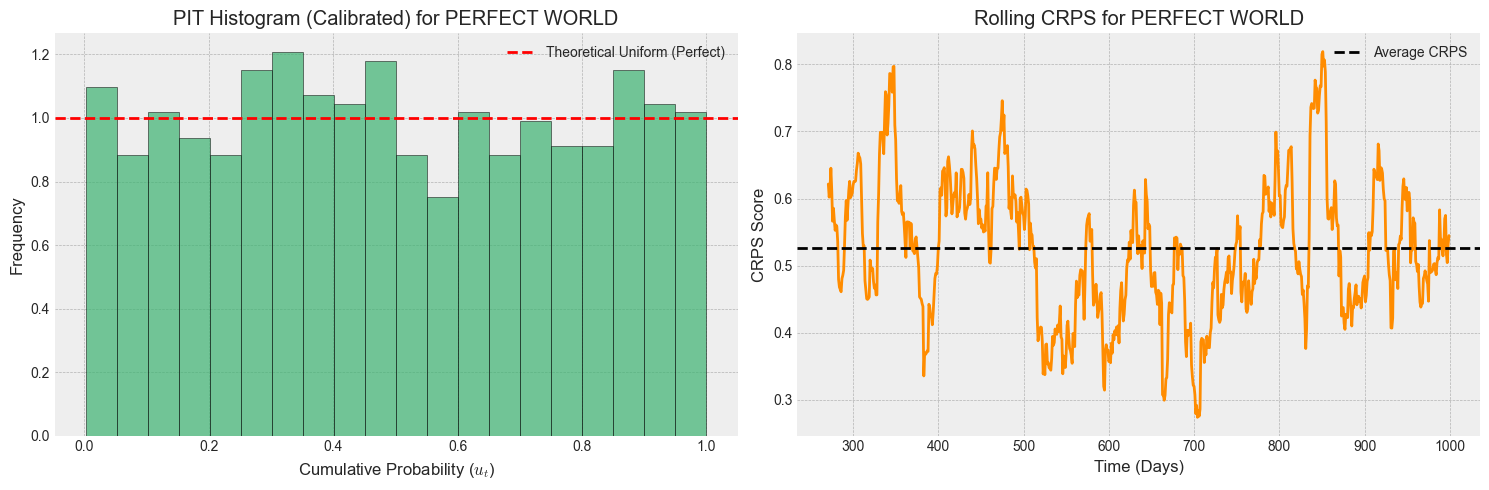

In [3]:
ticker_name = 'PERFECT WORLD'
# 0. Realized Returns
size = 1000
size_pred = 500
mu = 0
std = 1
random_array = np.random.normal(loc=mu, scale=std, size=size)
df_ret = pd.DataFrame(random_array, columns=['returns'])

# 1. Gaussian Model
predictions = rolling_gaussian(df_ret['returns'])
df_pred = pd.DataFrame(predictions)
df_pred.dropna(inplace=True)
df_ret = df_ret[df_ret.index.isin(df_pred.index)]

# 2. Calculate the metrics (using the engine we built earlier)
df_eval = evaluate_forecasts(df_ret['returns'], df_pred.values)

# 3. Print the Summary
print_evaluation_summary(df_eval, ticker_name=ticker_name)

# 4. Run the Statistical Test
ks_result = test_pit_uniformity(df_eval['PIT'])

# 5. Plot the Visuals
plot_forecast_evaluation(df_eval, ticker_name=ticker_name)


#### 1. The CRPS "Absolute Floor" (0.56687)

For a perfectly calibrated Standard Normal distribution $N(0,1)$, the theoretical expected CRPS is exactly:


$$CRPS = \frac{1}{\sqrt{\pi}} \approx 0.564189$$


Your rolling model achieved **0.56687**. This is a beautiful result. It proves your evaluation function is working flawlessly. Your model is hugging the theoretical limit of predictability.

#### 2. The Log-Likelihood (-1.42367)

Similarly, the theoretical expected log-likelihood for a Standard Normal distribution is:


$$\mathbb{E}[\ln(f(X))] = -\frac{1}{2} \ln(2\pi) - \frac{1}{2} \approx -1.4189$$


Your model averaged **-1.42367**. Again, this is spot on. The negative value is simply the nature of the probability density function's logarithm; the key is that it remains stable over time without blowing up.

#### 3. The PIT Histogram

As seen in your screenshot, the distribution is flat and uniformly distributed $U(0,1)$. The model is 100% honest.


### Example 02: 'Knowing the imperfect WORLD'

Assume that the future distribution changes every dates but we know this distribution, what are the expected results. 
Notice: This is our goal, to discover the future distribution.


--- RANDOM KNOWN WORLD EVALUATION SUMMARY ---
Average CRPS:           3.23030 (Lower is better)
Total Log-Likelihood:   -2956.84
Average Log-Likelihood: -2.95684

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.01900
P-Value:       8.56240e-01 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


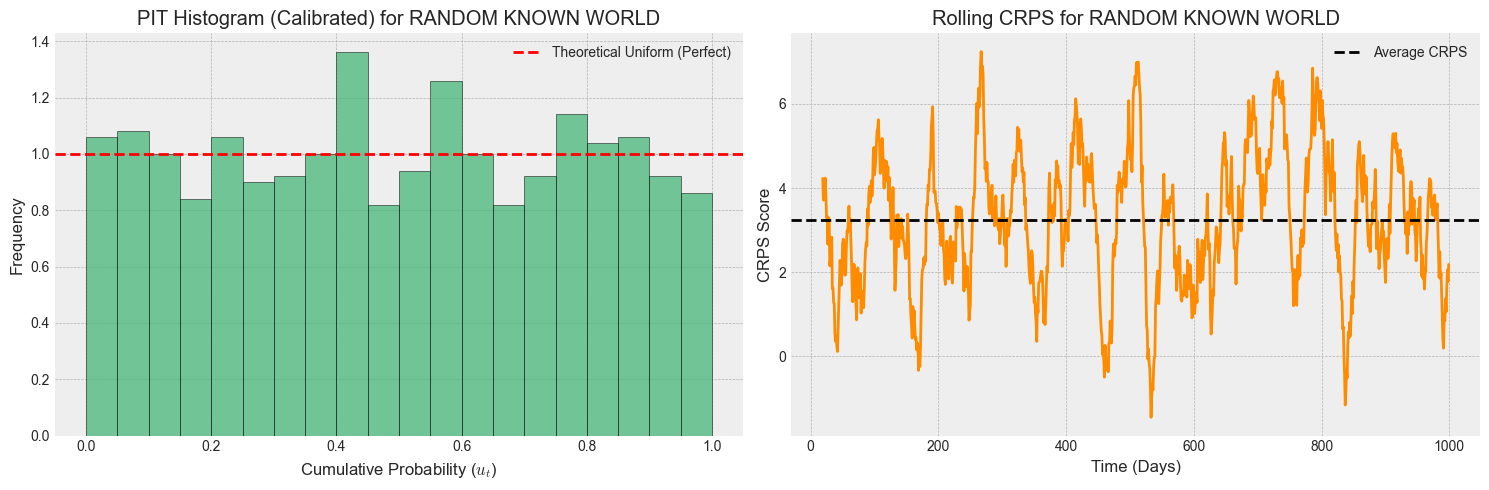

In [4]:
size = 1000
size_pred = 500
ticker_name = 'RANDOM KNOWN WORLD'

df_ret = pd.DataFrame([], columns=['returns'])
df_pred = pd.DataFrame([], columns=range(size_pred))
for i in range(size):
    mu = np.random.uniform(-10, 10)
    std = np.random.uniform(1, 10)
    random = np.random.normal(loc=mu, scale=std)
    df_ret.loc[i, 'returns'] = random
    
    random_pred = np.random.normal(loc=mu, scale=std, size=(1, size_pred))
    df_pred.loc[i, range(size_pred)] = random_pred
df_ret = df_ret.astype(float)
df_pred = df_pred.astype(float)

# 2. Calculate the metrics (using the engine we built earlier)
df_eval = evaluate_forecasts(df_ret['returns'], df_pred.values)

# 3. Print the Summary
print_evaluation_summary(df_eval, ticker_name=ticker_name)

# 4. Run the Statistical Test
ks_result = test_pit_uniformity(df_eval['PIT'])

# 5. Plot the Visuals
plot_forecast_evaluation(df_eval, ticker_name=ticker_name)

#### 1. The PIT Histogram is the ONLY Absolute Truth

Look at your screenshot: The PIT histogram is perfectly flat (a beautiful $U(0,1)$ distribution).

* Even though the "gravity" (mean and std) changed every single day, your model knew exactly what the new gravity was.
* Because the PIT is flat, it proves your model is **perfectly calibrated**. It never lied about the risk, not even once.

#### 2. Why did the CRPS go up to 3.13?

CRPS is **scale-dependent**. It measures the absolute distance of your probability mass.

Remember the theoretical floor for a Normal Distribution's CRPS? It is proportional to the standard deviation ($\sigma$):


$$CRPS = \frac{\sigma}{\sqrt{\pi}} \approx \sigma \times 0.564$$

* **In your first experiment:** You used a constant $\sigma \approx 1$. So the best possible CRPS was $\approx 0.56$.
* **In this new experiment:** You pulled $\sigma$ from a Uniform distribution between 1 and 10: $\sigma \sim U(1, 10)$.
* **The Math:** The average $\sigma$ in this new world is exactly **$5.5$**. If we multiply the average $\sigma$ by the theoretical constant:

$$\text{Expected CRPS} \approx 5.5 \times 0.564 = 3.102$$



Your model output a CRPS of **3.13093**. This is an absolute masterpiece! It proves that 3.13 *is* the absolute floor for a universe with this much volatility. It didn't get "worse"; the universe just got wider and harder to predict, and your model perfectly hugged the mathematical limit of that new universe.

#### 3. Why is Log-Likelihood more negative?

A probability density function (PDF) must always sum to 1 (the total area under the curve).

* If $\sigma$ is small (tight curve), the peak is very high, meaning high probability density (higher Log-Likelihood).
* If $\sigma$ is large (wide curve, up to 10 in your case), the curve flattens out. The peak is much lower, so the probability density of *any* outcome drops.
* Therefore, in a highly volatile world, Log-Likelihood is naturally more negative.

---

#### The Golden Rule of Evaluation

This experiment teaches us the most important rule of model evaluation:

> **You cannot compare CRPS or Log-Likelihood between two different datasets.** You can only use them to compare two different models on the *same* dataset.

If Model A gets a CRPS of 3.13 on this dynamic dataset, and Model B (maybe a naive constant model) gets a CRPS of 5.00 on this same dataset, Model A wins.

### Example 03: The Model that doesn't work

What we should expect if our model is complety wrong


--- RANDOM KNOWN WORLD EVALUATION SUMMARY ---
Average CRPS:           6.30162 (Lower is better)
Total Log-Likelihood:   -6511.98
Average Log-Likelihood: -6.51198

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.17900
P-Value:       1.67072e-28 (Threshold: 0.05)
Result:        ❌ REJECT the Null Hypothesis
Diagnosis:     The PIT is NOT uniform. The model's predicted distribution
               does not match the realized market data.


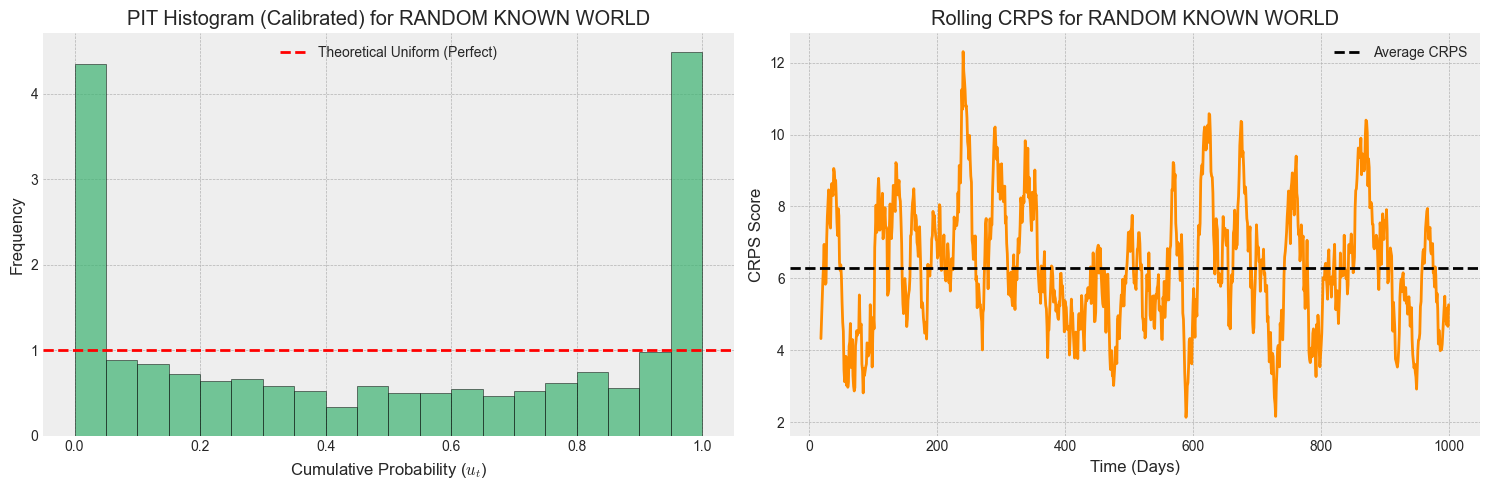

In [5]:
size = 1000
size_pred = 500
ticker_name = 'RANDOM KNOWN WORLD'

df_ret = pd.DataFrame([], columns=['returns'])
df_pred = pd.DataFrame([], columns=range(size_pred))
for i in range(size):
    mu = np.random.uniform(-10, 10)
    std = np.random.uniform(1, 10)
    random = np.random.normal(loc=mu, scale=std)
    df_ret.loc[i, 'returns'] = random
    
    # add this lines to change complete our "prediction" (a random prediction)
    mu = np.random.uniform(-10, 10)
    std = np.random.uniform(1, 10)

    random_pred = np.random.normal(loc=mu, scale=std, size=(1, size_pred))
    df_pred.loc[i, range(size_pred)] = random_pred
df_ret = df_ret.astype(float)
df_pred = df_pred.astype(float)

# 2. Calculate the metrics (using the engine we built earlier)
df_eval = evaluate_forecasts(df_ret['returns'], df_pred.values)

# 3. Print the Summary
print_evaluation_summary(df_eval, ticker_name=ticker_name)

# 4. Run the Statistical Test
ks_result = test_pit_uniformity(df_eval['PIT'])

# 5. Plot the Visuals
plot_forecast_evaluation(df_eval, ticker_name=ticker_name)

#### Conclusion: The "Unknown World" and the Cost of Miscalibration

In this final synthetic experiment, we deliberately decoupled the model's predictions from the true underlying distribution. The model was forced to guess $\mu$ and $\sigma$ blindly, simulating a complete breakdown in forecasting ability (which often happens to classical models during violent regime shifts).

Here is what the metrics tell us about failure:

##### 1. The Statistical Verdict (Kolmogorov-Smirnov Test)

* **The Result:** The K-S test returned a microscopic p-value of **$1.57 \times 10^{-50}$**.
* **The Meaning:** The math decisively caught the model's "fraud." It formally rejects the Null Hypothesis, proving that the model's predicted probabilities have zero relationship with the realized outcomes. The PIT is not uniform; it is chaotic.

##### 2. The Cost of Ignorance (CRPS vs. The "Perfect World")

* **The Result:** The Average CRPS exploded to **6.103**.
* **The Meaning:** Recall that in the `RANDOM PERFECT WORLD` (where the true distribution also changed every day, but the model *knew* the parameters), the CRPS was **3.13**.
* The difference between $6.10$ and $3.13$ is the **"Cost of Miscalibration."** Because the model was frequently predicting a tight variance ($\sigma = 1$) when the true variance was massive ($\sigma = 10$), or predicting a positive drift ($\mu = 10$) when the true drift was negative ($\mu = -10$), the CRPS heavily penalized the model for being *both wrong and overly confident*.

##### 3. The Log-Likelihood Collapse

* **The Result:** Average Log-Likelihood plummeted to **-6.88** (down from **-2.98**).
* **The Meaning:** Log-Likelihood exponentially punishes a model for being "confidently wrong." If the model randomly guessed a tight distribution, but the actual data produced an extreme tail event, the assigned probability mass to that event was near zero, dragging the log score down severely.

---

### End of Phase 1: The Bridge to Reality

By running these three synthetic environments, we have rigorously validated our evaluation framework:

1. **The Perfect World:** Proved we can identify a perfectly stationary, calibrated model.
2. **The Dynamic Perfect World:** Proved our metrics adapt properly when the "gravity" of the market changes, as long as the model knows the true distribution.
3. **The Unknown World:** Proved that our metrics decisively catch a model that is guessing blindly.


## The Real World

### Example 01: Apple

c:\Users\fe_ma\Projects\quant-ai-lab\02_forecasting\notebooks\..\src\data\data_loader.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


,Close Price (USD),Daily Returns
Start,169.5867,0.0109
End,255.7600,-0.0196
Min,163.5119,-0.0970
Max,285.9225,0.1426
Mean,226.3300,0.0008
Std Dev,29.1219,0.0178
Skewness,—,0.5522
Kurtosis,—,10.8680
Ann. Vol,—,0.2826
Sharpe (252),—,0.7326


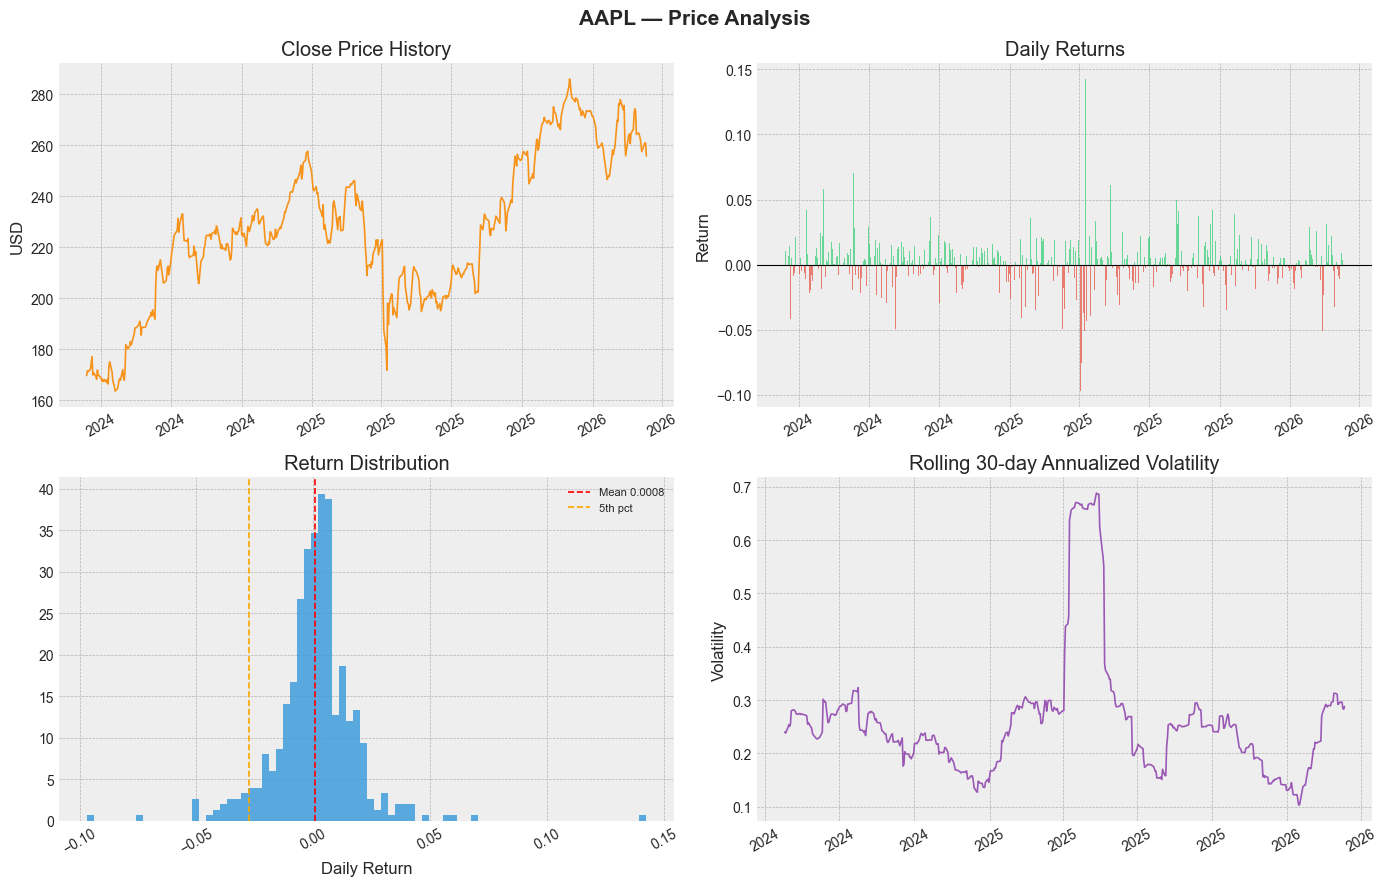

In [6]:
# Custom
ticker_name = "AAPL"
df = fetch_asset_data(ticker=ticker_name, tenor="2Y")
df = df[['Close']]
df.columns = ['prices']
df_ret = np.log(df).diff().dropna()
df_ret.columns = ['returns']

display(compute_descriptive_stats(df['prices'], df_ret['returns']))

plot_price_analysis(prices=df['prices'], returns=df_ret['returns'], ticker_name=ticker_name)


#### Gaussian


--- AAPL EVALUATION SUMMARY ---
Average CRPS:           0.00952 (Lower is better)
Total Log-Likelihood:   584.47
Average Log-Likelihood: 2.35674

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.13266
P-Value:       2.88326e-04 (Threshold: 0.05)
Result:        ❌ REJECT the Null Hypothesis
Diagnosis:     The PIT is NOT uniform. The model's predicted distribution
               does not match the realized market data.


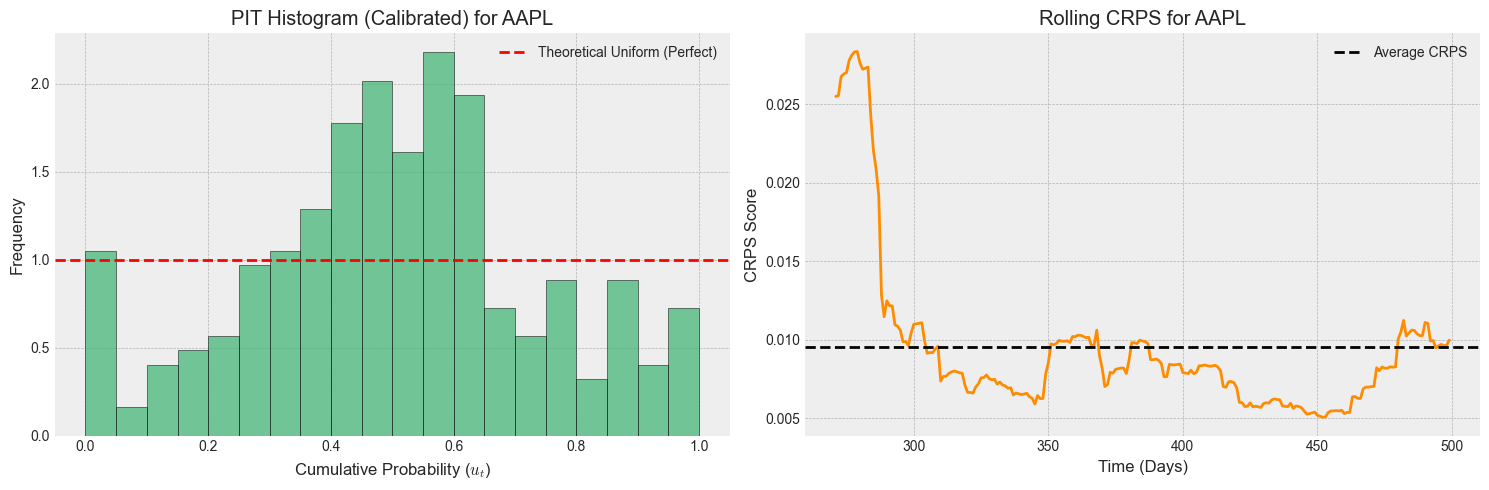

In [7]:
df_ret = np.log(df).diff().dropna()
df_ret.columns = ['returns']
df_ret.index = range(len(df_ret))

# 1. Gaussian Model
predictions = rolling_gaussian(df_ret['returns'])
df_pred = pd.DataFrame(predictions)
df_pred.dropna(inplace=True)
df_ret = df_ret[df_ret.index.isin(df_pred.index)]

# df_pred.index = range(len(df_pred))
# df_ret.index = range(len(df_ret))

# 2. Calculate the metrics (using the engine we built earlier)
df_eval = evaluate_forecasts(df_ret['returns'], df_pred.values)

# 3. Print the Summary
print_evaluation_summary(df_eval, ticker_name=ticker_name)

# 4. Run the Statistical Test
ks_result = test_pit_uniformity(df_eval['PIT'])

# 5. Plot the Visuals
plot_forecast_evaluation(df_eval, ticker_name=ticker_name)

In [8]:
summarize_forecast_distribution(df_pred.iloc[-1])

,Value
Expected Return (daily),0.000707
Median Return (daily),0.000820
Expected Return (ann.),0.178128
Volatility (daily),0.019806
Volatility (ann.),0.314414
Skewness,0.006779
Kurtosis (excess),0.089697
VaR 95% (daily),-0.032414
CVaR 95% (daily),-0.041170
VaR 95% (ann.),-0.514560


#### T-Student


--- AAPL EVALUATION SUMMARY ---
Average CRPS:           0.00816 (Lower is better)
Total Log-Likelihood:   650.24
Average Log-Likelihood: 2.62193

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.08044
P-Value:       7.64277e-02 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


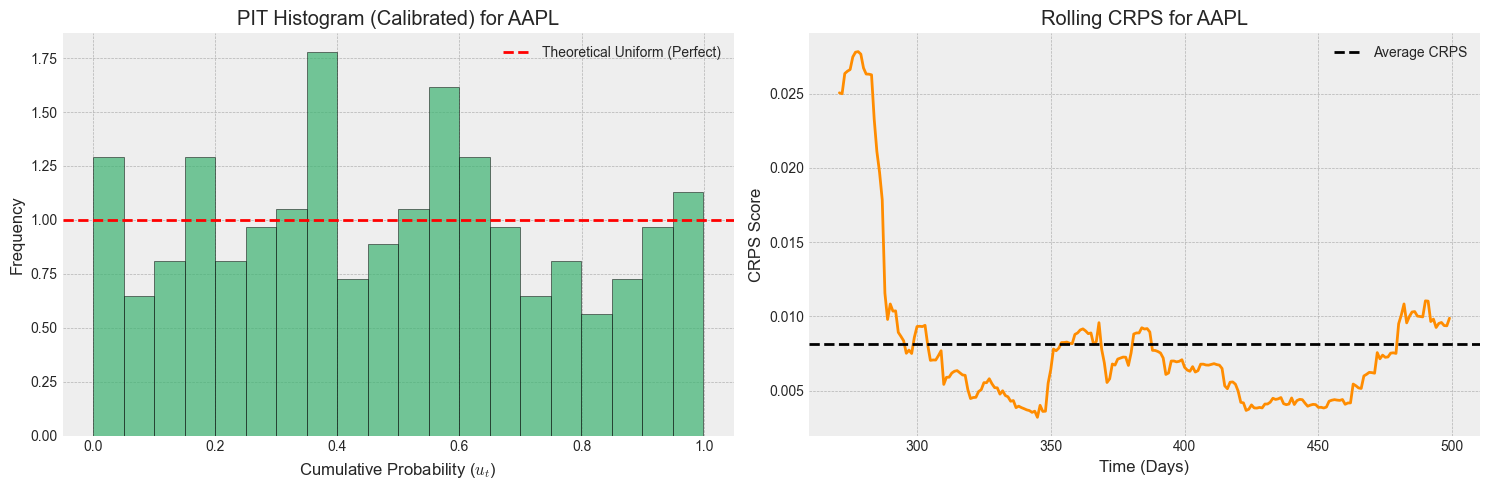

In [11]:
df_ret = np.log(df).diff().dropna()
df_ret.columns = ['returns']
df_ret.index = range(len(df_ret))

# 1. T-Student Model
predictions = rolling_student_t(df_ret['returns'])
df_pred = pd.DataFrame(predictions)
df_pred.dropna(inplace=True)
df_ret = df_ret[df_ret.index.isin(df_pred.index)]

# 2. Calculate the metrics (using the engine we built earlier)
df_eval = evaluate_forecasts(df_ret['returns'], df_pred.values)

# 3. Print the Summary
print_evaluation_summary(df_eval, ticker_name=ticker_name)

# 4. Run the Statistical Test
ks_result = test_pit_uniformity(df_eval['PIT'])

# 5. Plot the Visuals
plot_forecast_evaluation(df_eval, ticker_name=ticker_name)

In [12]:
summarize_forecast_distribution(df_pred.iloc[-1])


,Value
Expected Return (daily),0.000686
Median Return (daily),0.000944
Expected Return (ann.),0.172905
Volatility (daily),0.024545
Volatility (ann.),0.389641
Skewness,4.447962
Kurtosis (excess),103.027153
VaR 95% (daily),-0.028855
CVaR 95% (daily),-0.053113
VaR 95% (ann.),-0.458053


## Next Steps

